In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn jupyter

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cell 1 — Import Libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [3]:
# Cell 2 — Load Dataset 

print("Loading dataset... this may take 1-2 minutes ⏳")

df = pd.read_csv('2019-Oct.csv.gz', compression='gzip')

print(f"✅ Dataset Loaded!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

Loading dataset... this may take 1-2 minutes ⏳
✅ Dataset Loaded!
Shape: (42448764, 9)

Columns: ['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']

First 3 rows:


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8


In [4]:
# Cell 3 — Basic Exploration 

print("=== Dataset Info ===")
print(df.dtypes)
print(f"\n=== Missing Values ===")
print(df.isnull().sum())
print(f"\n=== Event Types (unique actions) ===")
print(df['event_type'].value_counts())
print(f"\n=== Total Unique Users ===")
print(df['user_id'].nunique())

=== Dataset Info ===
event_time           str
event_type           str
product_id         int64
category_id        int64
category_code        str
brand                str
price            float64
user_id            int64
user_session         str
dtype: object

=== Missing Values ===
event_time              0
event_type              0
product_id              0
category_id             0
category_code    13515609
brand             6117080
price                   0
user_id                 0
user_session            2
dtype: int64

=== Event Types (unique actions) ===
event_type
view        40779399
cart          926516
purchase      742849
Name: count, dtype: int64

=== Total Unique Users ===
3022290


In [5]:
# Cell 4 — Preprocessing (Filter Purchases Only)

# Keep only PURCHASE events (these generate revenue)
purchases = df[df['event_type'] == 'purchase'].copy()

# Drop rows with missing price or user_id
purchases.dropna(subset=['user_id', 'price'], inplace=True)

# Remove prices <= 0
purchases = purchases[purchases['price'] > 0]

# Convert event_time to datetime
purchases['event_time'] = pd.to_datetime(purchases['event_time'], utc=True)

# Convert user_id to integer
purchases['user_id'] = purchases['user_id'].astype(int)

print(f"✅ Preprocessing Done!")
print(f"Total Purchase Events : {len(purchases):,}")
print(f"Unique Customers      : {purchases['user_id'].nunique():,}")
print(f"Date Range            : {purchases['event_time'].min()} → {purchases['event_time'].max()}")
purchases.head(3)

✅ Preprocessing Done!
Total Purchase Events : 742,849
Unique Customers      : 347,118
Date Range            : 2019-10-01 00:02:14+00:00 → 2019-10-31 23:59:16+00:00


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
162,2019-10-01 00:02:14+00:00,purchase,1004856,2053013555631882655,electronics.smartphone,samsung,130.76,543272936,8187d148-3c41-46d4-b0c0-9c08cd9dc564
308,2019-10-01 00:04:37+00:00,purchase,1002532,2053013555631882655,electronics.smartphone,apple,642.69,551377651,3c80f0d6-e9ec-4181-8c5c-837a30be2d68
379,2019-10-01 00:06:02+00:00,purchase,5100816,2053013553375346967,NaN,xiaomi,29.51,514591159,0e5dfc4b-2a55-43e6-8c05-97e1f07fbb56


In [6]:
# Cell 5 — Feature Engineering (RFM)

# Reference date = 1 day after last purchase
reference_date = purchases['event_time'].max() + pd.Timedelta(days=1)

rfm = purchases.groupby('user_id').agg(
    Recency   = ('event_time',  lambda x: (reference_date - x.max()).days),
    Frequency = ('user_session','nunique'),
    Monetary  = ('price',       'sum')
).reset_index()

# CLTV target = total spend (Monetary)
rfm['CLTV'] = rfm['Monetary']

print("✅ RFM Table Created!")
print(f"Shape: {rfm.shape}")
print()
print(rfm.describe())

✅ RFM Table Created!
Shape: (347118, 5)

            user_id        Recency      Frequency       Monetary  \
count  3.471180e+05  347118.000000  347118.000000  347118.000000   
mean   5.359970e+08      14.599528       1.813677     662.476455   
std    1.849860e+07       8.670697       2.437539    2074.370475   
min    2.646498e+08       1.000000       1.000000       0.880000   
25%    5.171042e+08       7.000000       1.000000     107.590000   
50%    5.351679e+08      14.000000       1.000000     246.520000   
75%    5.548038e+08      21.000000       2.000000     595.015000   
max    5.662783e+08      31.000000     152.000000  265569.520000   

                CLTV  
count  347118.000000  
mean      662.476455  
std      2074.370475  
min         0.880000  
25%       107.590000  
50%       246.520000  
75%       595.015000  
max    265569.520000  


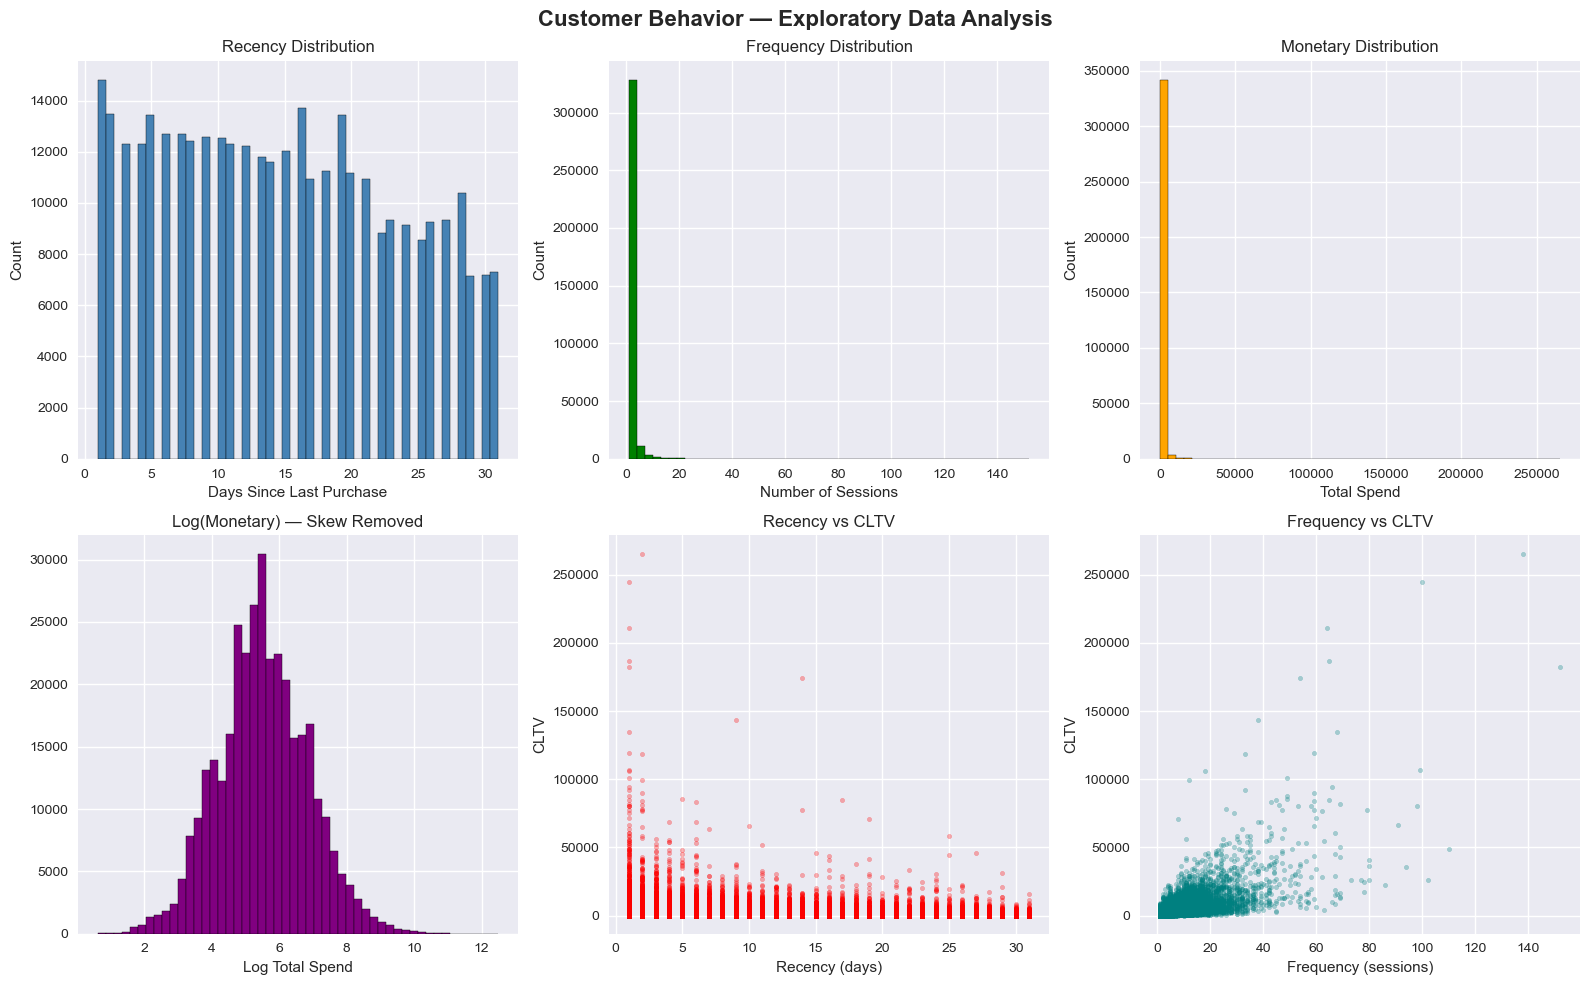

✅ EDA plots saved!


In [7]:
#  Cell 6 — EDA Visualizations

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Customer Behavior — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Recency
axes[0,0].hist(rfm['Recency'], bins=50, color='steelblue', edgecolor='black')
axes[0,0].set_title('Recency Distribution')
axes[0,0].set_xlabel('Days Since Last Purchase')
axes[0,0].set_ylabel('Count')

# Frequency
axes[0,1].hist(rfm['Frequency'], bins=50, color='green', edgecolor='black')
axes[0,1].set_title('Frequency Distribution')
axes[0,1].set_xlabel('Number of Sessions')
axes[0,1].set_ylabel('Count')

# Monetary
axes[0,2].hist(rfm['Monetary'], bins=50, color='orange', edgecolor='black')
axes[0,2].set_title('Monetary Distribution')
axes[0,2].set_xlabel('Total Spend')
axes[0,2].set_ylabel('Count')

# Log Monetary
axes[1,0].hist(np.log1p(rfm['Monetary']), bins=50, color='purple', edgecolor='black')
axes[1,0].set_title('Log(Monetary) — Skew Removed')
axes[1,0].set_xlabel('Log Total Spend')

# Recency vs CLTV
axes[1,1].scatter(rfm['Recency'], rfm['CLTV'], alpha=0.3, color='red', s=10)
axes[1,1].set_title('Recency vs CLTV')
axes[1,1].set_xlabel('Recency (days)')
axes[1,1].set_ylabel('CLTV')

# Frequency vs CLTV
axes[1,2].scatter(rfm['Frequency'], rfm['CLTV'], alpha=0.3, color='teal', s=10)
axes[1,2].set_title('Frequency vs CLTV')
axes[1,2].set_xlabel('Frequency (sessions)')
axes[1,2].set_ylabel('CLTV')

plt.tight_layout()
import os
os.makedirs('results', exist_ok=True)
plt.savefig('results/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved!")

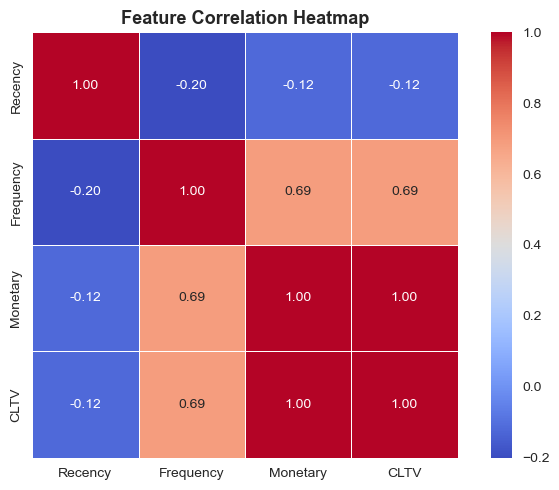

✅ Heatmap saved!


In [8]:
# Cell 7 — Correlation Heatmap 

plt.figure(figsize=(7, 5))
corr = rfm[['Recency', 'Frequency', 'Monetary', 'CLTV']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/correlation_heatmap.png', dpi=150)
plt.show()
print("✅ Heatmap saved!")

In [9]:
# Cell 8 — Prepare Data for ML 

# Remove top 1% outliers
rfm_clean = rfm[rfm['CLTV'] < rfm['CLTV'].quantile(0.99)].copy()

# Log-transform target to reduce skewness
rfm_clean['CLTV_log'] = np.log1p(rfm_clean['CLTV'])

# Features and Target
X = rfm_clean[['Recency', 'Frequency', 'Monetary']]
y = rfm_clean['CLTV_log']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✅ Data Ready for ML!")
print(f"Training samples : {X_train.shape[0]:,}")
print(f"Testing samples  : {X_test.shape[0]:,}")
print(f"Features         : {list(X.columns)}")

✅ Data Ready for ML!
Training samples : 274,916
Testing samples  : 68,730
Features         : ['Recency', 'Frequency', 'Monetary']


In [10]:
# Cell 9 — Train All Models

models = {
    'Linear Regression'   : LinearRegression(),
    'Ridge Regression'    : Ridge(alpha=1.0),
    'Lasso Regression'    : Lasso(alpha=0.01),
    'Random Forest'       : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

print("Training models...\n")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"✅ {name:25s} | R²: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print("\n🏆 Model Leaderboard:")
results_df

Training models...

✅ Linear Regression         | R²: 0.5823 | MAE: 0.6539 | RMSE: 0.8314
✅ Ridge Regression          | R²: 0.5823 | MAE: 0.6539 | RMSE: 0.8314
✅ Lasso Regression          | R²: 0.5822 | MAE: 0.6549 | RMSE: 0.8315
✅ Random Forest             | R²: 1.0000 | MAE: 0.0000 | RMSE: 0.0001
✅ Gradient Boosting         | R²: 0.9999 | MAE: 0.0081 | RMSE: 0.0111

🏆 Model Leaderboard:


,MAE,RMSE,R2
Random Forest,0.000014,0.000107,1.000000
Gradient Boosting,0.008056,0.011085,0.999926
Linear Regression,0.653883,0.831384,0.582319
Ridge Regression,0.653883,0.831384,0.582319
Lasso Regression,0.654950,0.831455,0.582248


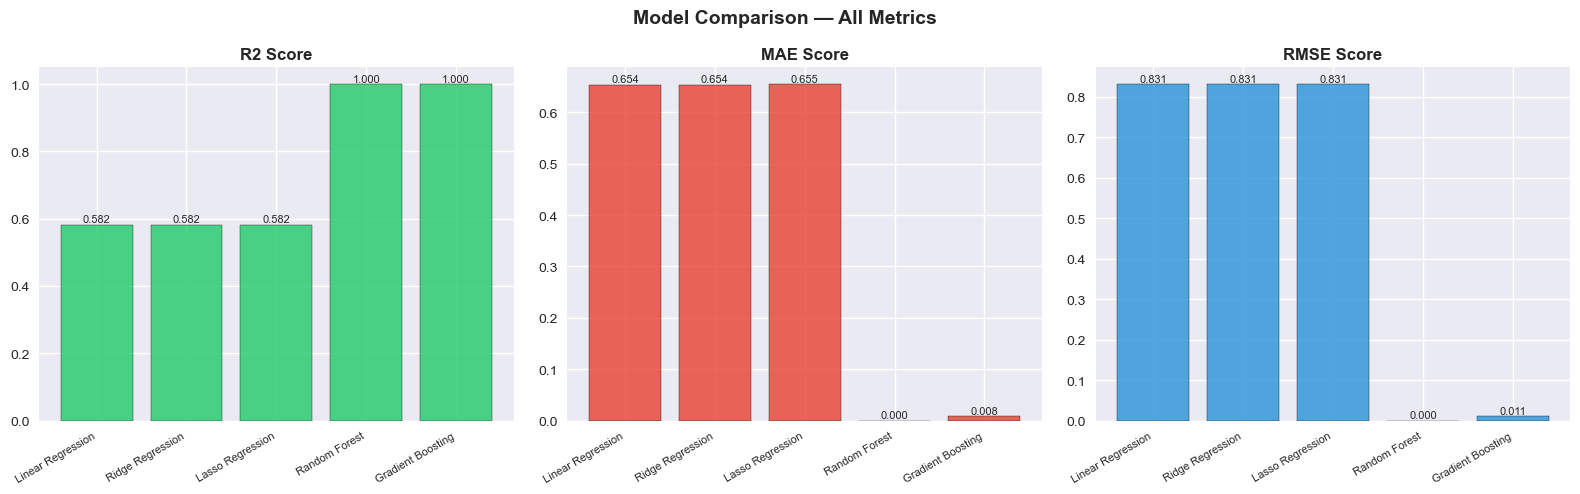

✅ Model comparison chart saved!


In [11]:
# Cell 10 — Model Comparison Chart 

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison — All Metrics', fontsize=14, fontweight='bold')

metrics = ['R2', 'MAE', 'RMSE']
colors  = ['#2ecc71', '#e74c3c', '#3498db']
labels  = list(models.keys())

for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = [results[m][metric] for m in labels]
    bars = axes[i].bar(labels, vals, color=color, alpha=0.85, edgecolor='black')
    axes[i].set_title(f'{metric} Score', fontsize=12, fontweight='bold')
    axes[i].set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.001,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('results/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model comparison chart saved!")

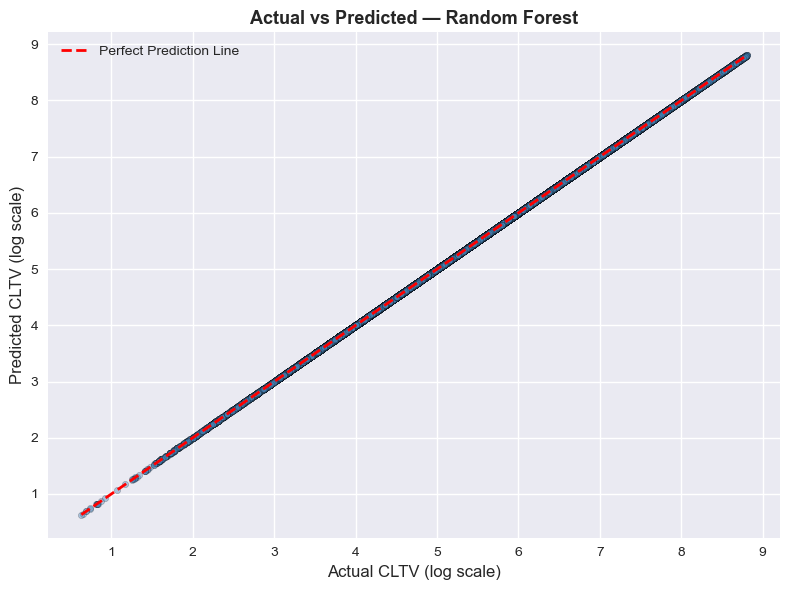


🏆 Best Model  : Random Forest
   R² Score   : 1.0000
   MAE        : 0.0000
   RMSE       : 0.0001


In [12]:
# Cell 11 — Best Model: Actual vs Predicted 

best_name  = results_df['R2'].idxmax()
best_model = models[best_name]
y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4, color='steelblue',
            edgecolors='black', linewidths=0.3, s=20)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual CLTV (log scale)', fontsize=12)
plt.ylabel('Predicted CLTV (log scale)', fontsize=12)
plt.title(f'Actual vs Predicted — {best_name}', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('results/feature_importance.png', dpi=150)
plt.show()

print(f"\n🏆 Best Model  : {best_name}")
print(f"   R² Score   : {results[best_name]['R2']:.4f}")
print(f"   MAE        : {results[best_name]['MAE']:.4f}")
print(f"   RMSE       : {results[best_name]['RMSE']:.4f}")

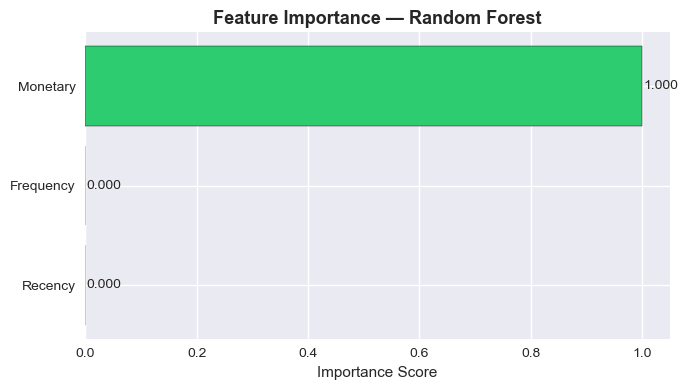

✅ Feature importance chart saved!


In [13]:
# Cell 12 — Feature Importance 

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    features    = ['Recency', 'Frequency', 'Monetary']

    plt.figure(figsize=(7, 4))
    colors_fi = ['#e74c3c', '#3498db', '#2ecc71']
    bars = plt.barh(features, importances, color=colors_fi, edgecolor='black')
    plt.xlabel('Importance Score', fontsize=11)
    plt.title(f'Feature Importance — {best_name}', fontsize=13, fontweight='bold')
    for bar, val in zip(bars, importances):
        plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150)
    plt.show()
    print("✅ Feature importance chart saved!")
else:
    print(f"ℹ️ {best_name} doesn't support feature importance directly.")

In [14]:
# Cell 13 — Final Summary 

print("=" * 55)
print("   CUSTOMER LIFETIME VALUE PREDICTION — SUMMARY")
print("=" * 55)
print(f"  Dataset          : eCommerce Behavior (Oct 2019)")
print(f"  Total Customers  : {rfm_clean.shape[0]:,}")
print(f"  Features Used    : Recency, Frequency, Monetary")
print(f"  Models Tested    : {len(models)}")
print(f"  Best Model       : {best_name}")
print(f"  Best R² Score    : {results[best_name]['R2']:.4f}")
print(f"  Best MAE         : {results[best_name]['MAE']:.4f}")
print(f"  Best RMSE        : {results[best_name]['RMSE']:.4f}")
print("=" * 55)
print("\n📁 Saved Files:")
print("   → eda_plots.png")
print("   → correlation_heatmap.png")
print("   → model_comparison.png")
print("   → actual_vs_predicted.png")
print("   → feature_importance.png")
print("\n✅ Project Complete! Good luck at the exhibition! 🚀")

   CUSTOMER LIFETIME VALUE PREDICTION — SUMMARY
  Dataset          : eCommerce Behavior (Oct 2019)
  Total Customers  : 343,646
  Features Used    : Recency, Frequency, Monetary
  Models Tested    : 5
  Best Model       : Random Forest
  Best R² Score    : 1.0000
  Best MAE         : 0.0000
  Best RMSE        : 0.0001

📁 Saved Files:
   → eda_plots.png
   → correlation_heatmap.png
   → model_comparison.png
   → actual_vs_predicted.png
   → feature_importance.png

✅ Project Complete! Good luck at the exhibition! 🚀


In [15]:
#  Cell 14 — Live Interactive Predictor 

import numpy as np

print("=" * 55)
print("      CLTV PREDICTION — LIVE DEMO")
print("=" * 55)

def predict_cltv_live(recency, frequency, monetary):
    # Use the same scaler and best_model from your notebook
    input_data = np.array([[recency, frequency, monetary]])
    input_scaled = scaler.transform(input_data)
    cltv_log_pred = best_model.predict(input_scaled)[0]
    cltv_pred = np.expm1(cltv_log_pred)  # reverse log transform
    return round(cltv_pred, 2)

def get_segment(cltv):
    if cltv > 10000:
        return "🟢 HIGH VALUE CUSTOMER — Priority Retention!"
    elif cltv > 3000:
        return "🟡 MID VALUE CUSTOMER — Nurture & Grow"
    else:
        return "🔴 LOW VALUE CUSTOMER — Re-engagement Needed"

while True:
    print("\nEnter customer details (or type 'exit' to quit):\n")

    r = input("  Recency   → Days since last purchase : ")
    if r.lower() == 'exit':
        print("\n✅ Demo ended. Thank you!")
        break

    f = input("  Frequency → Number of sessions       : ")
    m = input("  Monetary  → Total amount spent (₹)   : ")

    try:
        recency   = float(r)
        frequency = float(f)
        monetary  = float(m)

        cltv = predict_cltv_live(recency, frequency, monetary)
        segment = get_segment(cltv)

        print("\n" + "─" * 55)
        print(f"  Recency   : {recency} days")
        print(f"  Frequency : {frequency} sessions")
        print(f"  Monetary  : ₹{monetary:,.2f}")
        print("─" * 55)
        print(f"  Predicted CLTV  : ₹{cltv:,.2f}")
        print(f"  Customer Segment: {segment}")
        print("─" * 55)

        print(f"\n  Best Model Used : {best_name}")
        print(f"  R² Score        : {results[best_name]['R2']:.4f}")
        print("─" * 55)

    except ValueError:
        print("⚠️  Please enter valid numbers only!")

      CLTV PREDICTION — LIVE DEMO

Enter customer details (or type 'exit' to quit):



  Recency   → Days since last purchase :  exit



✅ Demo ended. Thank you!


In [18]:
# Cell 14 — Export Model Values & Launch Demo 

import json

# Collect all model R2 scores
model_scores = {name: round(metrics['R2'], 4) for name, metrics in results.items()}

# Save to a JS file so demo.html can read it
js_content = f"""
const MODEL_SCORES = {json.dumps(model_scores, indent=2)};
const BEST_MODEL = "{best_name}";
const BEST_R2 = {round(results[best_name]['R2'], 4)};
const TOTAL_CUSTOMERS = {rfm_clean.shape[0]};
"""

with open('model_data.js', 'w') as f:
    f.write(js_content)

print("✅ model_data.js saved!")
print(f"\nNow open demo.html in your browser!")
print(f"📁 File location: same folder as this notebook")

✅ model_data.js saved!

Now open demo.html in your browser!
📁 File location: same folder as this notebook
